In [4]:
"""
Created on Fri Aug 15 2025

@author: vanln@ntnu.no
"""

'\nCreated on Fri Aug 15 2025\n\n@author: vanln@ntnu.no\n'

# **Run several Machine Learning classification models to assess the condition of the drainage pipeline system in the city of Ålesund, Norway**

# Machine Learning Models used:
####    1. Logistic Regression
####    2. K-Nearest Neighbour (KNN)
####    3. Decision Tree
####    4. Random Forest
####    5. Support Vector Machine (SVM)
####    6. Multi-layer Perceptron

## Import libraries

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import auc, roc_curve

## Read data

In [2]:
train_data = "Training.csv"
test_data = "Testing.csv"
data_train = pd.read_csv(train_data)
data_test = pd.read_csv(test_data)

In [3]:
data_train.head()

,PipeID,Age,Diameter,Depth,Slope,Length,Pipe_Type,Connection_Type,Pipe_Form,Material,...,Geology,Groundwater,Soil_Type,Landslide_Area,Population,Building_Area,Land_Cover,Distance_to_Road,Traffic_Volume,Condition_Classes
0,59707,52,200,-0.73,3.33,46.32,Wastewater,MUF,S,BET,...,Geology-0,16.75,SoilType-4,No,66,No,LandCover-2,RoadClass-0,0,0
1,41001,59,200,-1.58,11.38,23.36,Wastewater,MUF,S,PVC,...,Geology-2,15.53,SoilType-2,No,139,No,LandCover-1,RoadClass-0,0,0
2,164152,1,200,-2.02,-1.59,45.83,Stormwater,Others,S,PVC,...,Geology-2,23.33,SoilType-5,No,94,No,LandCover-1,RoadClass-0,0,0
3,66538,35,200,-2.03,4.69,33.43,Wastewater,Others,S,PVC,...,Geology-2,32.63,SoilType-5,No,130,No,LandCover-2,RoadClass-3,0,0
4,66840,36,200,-0.50,0.42,56.01,Combined,Others,S,PVC,...,Geology-2,40.14,SoilType-4,No,79,No,LandCover-2,RoadClass-2,0,0


## Process data

In [4]:
# Remove unnecessary columns
column_drop = ["PipeID"]
data_train_new = data_train.drop(columns=column_drop)
data_test_new = data_test.drop(columns=column_drop)

In [9]:
data_train_new.head()

,Age,Diameter,Depth,Slope,Length,Pipe_Type,Connection_Type,Pipe_Form,Material,Rainfall,Geology,Groundwater,Soil_Type,Landslide_Area,Population,Building_Area,Land_Cover,Distance_to_Road,Traffic_Volume,Condition_Classes
0,52,200,-0.73,3.33,46.32,Wastewater,MUF,S,BET,127.08,Geology-0,16.75,SoilType-4,No,66,No,LandCover-2,RoadClass-0,0,0
1,59,200,-1.58,11.38,23.36,Wastewater,MUF,S,PVC,109.49,Geology-2,15.53,SoilType-2,No,139,No,LandCover-1,RoadClass-0,0,0
2,1,200,-2.02,-1.59,45.83,Stormwater,Others,S,PVC,144.65,Geology-2,23.33,SoilType-5,No,94,No,LandCover-1,RoadClass-0,0,0
3,35,200,-2.03,4.69,33.43,Wastewater,Others,S,PVC,130.31,Geology-2,32.63,SoilType-5,No,130,No,LandCover-2,RoadClass-3,0,0
4,36,200,-0.50,0.42,56.01,Combined,Others,S,PVC,125.98,Geology-2,40.14,SoilType-4,No,79,No,LandCover-2,RoadClass-2,0,0


In [10]:
# Prepare data for training and testing
x_train = data_train_new.drop(columns=["Condition_Classes"])
y_train = data_train_new["Condition_Classes"].values
x_test = data_test_new.drop(columns=["Condition_Classes"])
y_test = data_test_new["Condition_Classes"].values

In [11]:
# Convert character variable in the training dataset to numeric
ordinalEncoder = OrdinalEncoder()
lb_column_new = [
    "Pipe_Type",
    "Connection_Type",
    "Pipe_Form",
    "Material",
    "Geology",
    "Soil_Type",
    "Landslide_Area",
    "Building_Area",
    "Land_Cover",
    "Distance_to_Road",
]
x_train[lb_column_new] = ordinalEncoder.fit_transform(x_train[lb_column_new])
x_test[lb_column_new] = ordinalEncoder.fit_transform(x_test[lb_column_new])
# Standardize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train)
X_train = scaler.transform(x_train)
X_test = scaler.transform(x_test)

## Machine Learning models Implementation

In [12]:
# Create a common list to store metrics of each model for comparison
metrics = []

## 1. Logistic Regression

In [13]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
LG_model = LogisticRegression(random_state=42, penalty="l2", C=pow(2, -5), solver="newton-cg")
# Train model
LG_result = LG_model.fit(X_train, y_train)
# Evaluate model
y_pred = LG_result.predict(X_test)
proba = LG_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["Logistic Regression", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.73
F1 score: 0.72


,Actual,Predicted,Confidence
0,0,0,0.555383
1,1,0,0.502172
2,1,1,0.518622
3,0,0,0.850452
4,0,0,0.830147
...,...,...,...
285,1,1,0.531096
286,1,1,0.536642
287,0,0,0.702935
288,0,0,0.614120


## 2. K-Nearest Neighbour (KNN)

In [14]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
KNN_model = KNeighborsClassifier(
    n_neighbors=21, weights="uniform", metric="manhattan", algorithm="ball_tree"
)
# Train model
KNN_result = KNN_model.fit(X_train, y_train)
# Evaluate model
y_pred = KNN_result.predict(X_test)
proba = KNN_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["K-Nearest Neighbors", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.73
F1 score: 0.73


,Actual,Predicted,Confidence
0,0,0,0.619048
1,1,0,0.523810
2,1,1,0.619048
3,0,0,0.952381
4,0,0,1.000000
...,...,...,...
285,1,1,0.571429
286,1,1,0.619048
287,0,0,0.571429
288,0,0,0.619048


## 3. Decision Tree

In [15]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
DT_model = DecisionTreeClassifier(random_state=42, criterion="gini", max_features=17)
# Train model
DT_result = DT_model.fit(X_train, y_train)
# Evaluate model
y_pred = DT_result.predict(X_test)
proba = DT_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["Decision Tree", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred})
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.71
F1 score: 0.70


,Actual,Predicted,Confidence
0,0,1,1.0
1,1,0,1.0
2,1,1,1.0
3,0,1,1.0
4,0,0,1.0
...,...,...,...
285,1,1,1.0
286,1,1,1.0
287,0,0,1.0
288,0,0,1.0


## 4. Random Forest

In [16]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
RF_model = RandomForestClassifier(
    random_state=42, criterion="entropy", n_estimators=260, max_features=19
)
# Train model
RF_result = RF_model.fit(X_train, y_train)
# Evaluate model
y_pred = RF_result.predict(X_test)
proba = RF_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["Random Forest", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.78
F1 score: 0.78


,Actual,Predicted,Confidence
0,0,0,0.542308
1,1,1,0.592308
2,1,1,0.746154
3,0,0,0.815385
4,0,0,1.000000
...,...,...,...
285,1,1,0.565385
286,1,1,0.730769
287,0,0,0.530769
288,0,1,0.700000


## 5. Support Vector Machine (SVM)

In [17]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
SVM_model = SVC(
    random_state=42, kernel="poly", C=pow(2, 3), degree=5, gamma=pow(2, -3), probability=True
)
# Train model
SVM_result = SVM_model.fit(X_train, y_train)
# Evaluate model
y_pred = SVM_result.predict(X_test)
proba = SVM_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["Support Vector Machine", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.74
F1 score: 0.74


,Actual,Predicted,Confidence
0,0,1,0.529375
1,1,1,0.573956
2,1,1,0.532697
3,0,0,0.894236
4,0,0,0.902846
...,...,...,...
285,1,1,0.661090
286,1,1,0.545942
287,0,0,0.665439
288,0,0,0.594230


## 6. Multilayer Perceptron

In [18]:
# Initialize model using default parameters
# More details: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
MLP_model = MLPClassifier(
    early_stopping=True, random_state=42, activation="tanh", solver="adam", hidden_layer_sizes=99
)
# Train model
MLP_result = MLP_model.fit(X_train, y_train)
# Evaluate model
y_pred = MLP_result.predict(X_test)
proba = MLP_result.predict_proba(X_test)
confidence = np.max(proba, axis=1)
# Store model metrics
metrics.append(["Multilayer Perceptron", y_test, proba[:, 1]])
# Print result
print("Accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("F1 score: %.2f" % f1_score(y_test, y_pred, average="weighted"))
pd.DataFrame(data={"Actual": y_test, "Predicted": y_pred, "Confidence": confidence.tolist()})

Accuracy: 0.71
F1 score: 0.71


,Actual,Predicted,Confidence
0,0,0,0.611274
1,1,0,0.583414
2,1,1,0.505519
3,0,0,0.886198
4,0,0,0.872630
...,...,...,...
285,1,1,0.506712
286,1,1,0.525053
287,0,0,0.775213
288,0,0,0.652687


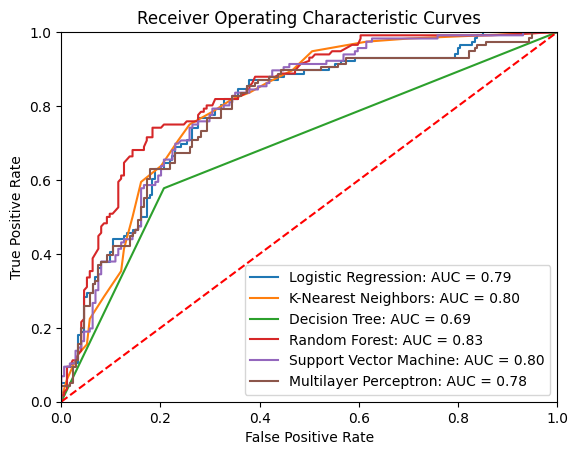

In [19]:
# Plot ROC curves
for item in metrics:
    fpr, tpr, thresholds = roc_curve(item[1], item[2])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{item[0]}: AUC = %0.2f" % roc_auc)
    plt.legend(loc="lower right")
plt.title("Receiver Operating Characteristic Curves")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

## Save model for future use

In [20]:
# Select model to predic
model = RF_result
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

# Data preparation for future data

In [21]:
# Read data used for prediction
new_data = pd.read_csv("2030_data.csv")
# Remove unnecessary columns
df_new = new_data.drop(columns=column_drop)
# Convert character variable in the training dataset to numeric
df_new[lb_column_new] = ordinalEncoder.fit_transform(df_new[lb_column_new])
# Standardize data
X_pred = scaler.transform(df_new)

# Prediction for future data

In [22]:
# # Load model
# with open('model.pkl', 'rb') as file:
#     model = pickle.load(file)
# Make prediction
y_pred = model.predict(X_pred)
proba = model.predict_proba(X_pred)
confidence = np.max(proba, axis=1)
# Print result
prediction = pd.DataFrame(data={"Predicted": y_pred, "Confidence": confidence.tolist()})

In [23]:
prediction

,Predicted,Confidence
0,0,0.553846
1,1,0.534615
2,1,0.669231
3,1,0.580769
4,1,0.715385
...,...,...
31288,0,0.507692
31289,0,0.619231
31290,0,0.750000
31291,0,0.707692


## Save prediction

In [30]:
prediction.to_csv("2030_prediction.csv", index=False)